In [1]:
# =============================================================================
# BCM Model Comparison: Individual Profile Analysis
# =============================================================================
# This notebook compares BCM (Baryonic Correction Model) predictions against
# TNG hydrodynamical simulations using INDIVIDUAL halo profiles.
#
# Key improvement: Instead of comparing stacked/averaged profiles (which can
# hide mass-dependent biases), we compare halo-by-halo and aggregate statistics.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import h5py 
import scienceplots
plt.style.use(['science','notebook', 'grid'])

# BCM libraries
try:
    import BaryonForge as bfg
    import pyccl as ccl
    print("BaryonForge and CCL imported successfully")
except ImportError as e:
    print(f"Import error: {e}")
    print("Install with: pip install BaryonForge pyccl")

# Constants
h = 0.6774
BOX_SIZE = 205.0  # Mpc/h

BaryonForge and CCL imported successfully


In [9]:
# =============================================================================
# Load ALL individual profiles from TNG and BCM files
# =============================================================================

BASE_TNG = '/mnt/home/mlee1/ceph/hydro_replace_fields/L205n2500TNG/profiles'
BASE_BCM = '/mnt/home/mlee1/ceph/hydro_replace_fields_bcm/L205n2500TNG/profiles'

# Load TNG profiles (DMO + Hydro individual profiles)
with h5py.File(f'{BASE_TNG}/profiles_snap096.h5', 'r') as f:
    # Individual profiles for ALL halos (9528, 30)
    tng_hydro_individual = f['individual_hydro_density'][:]
    tng_dmo_individual = f['individual_dmo_density'][:]
    tng_hydro_dm = f['individual_hydro_density_dm'][:]      # DM component in hydro
    tng_hydro_gas = f['individual_hydro_density_gas'][:]    # Gas component
    tng_hydro_stars = f['individual_hydro_density_stars'][:] # Stars component
    
    # Halo metadata
    halo_log_masses = f['halo_log_masses'][:]  # log10(M200c) in Msun/h
    halo_radii = f['halo_radii'][:]            # R200c in kpc/h
    
    # Radial bins
    r_bins = f.attrs['radial_bins']
    
    # Stacked profiles for reference
    stacked_dmo = f['stacked_dmo'][:]
    stacked_hydro = f['stacked_hydro'][:]

# Compute bin centers
r = np.sqrt(r_bins[1:] * r_bins[:-1])  # geometric mean

# =============================================================================
# Define CUSTOM mass bins: 12-12.5, 12.5-13, 13-13.5, >13.5
# =============================================================================
mass_bin_edges = np.array([12.0, 12.5, 13.0, 13.5, 16.0])  # last bin is >13.5
n_mass_bins = len(mass_bin_edges) - 1

# Compute mass bin indices for each halo
mass_bin_indices = np.digitize(halo_log_masses, mass_bin_edges) - 1
# Clip to valid range (halos outside bins get assigned to edge bins)
# mass_bin_indices = np.clip(mass_bin_indices, 0, n_mass_bins - 1)

# Count halos per bin
n_halos_per_bin = np.array([np.sum(mass_bin_indices == bi) for bi in range(n_mass_bins)])

# Mass bin labels for plotting
mass_bin_labels = [
    r'$12.0 \leq \log (M / {\rm M}_\odot) < 12.5$',
    r'$12.5 \leq \log (M / {\rm M}_\odot)  < 13.0$',
    r'$13.0 \leq \log (M / {\rm M}_\odot)  < 13.5$',
    r'$\log (M / {\rm M}_\odot)  \geq 13.5$',
]

print(f"Loaded {len(halo_log_masses)} halos")
print(f"Radial bins: {len(r)} points from {r.min():.3f} to {r.max():.2f} R200")
print(f"\nCustom mass bins:")
for bi in range(n_mass_bins):
    m_lo, m_hi = mass_bin_edges[bi], mass_bin_edges[bi+1]
    print(f"  Bin {bi}: {m_lo:.1f} - {m_hi:.1f} -> {n_halos_per_bin[bi]} halos")

Loaded 28375 halos
Radial bins: 30 points from 0.011 to 4.51 R200

Custom mass bins:
  Bin 0: 12.0 - 12.5 -> 18847 halos
  Bin 1: 12.5 - 13.0 -> 6602 halos
  Bin 2: 13.0 - 13.5 -> 2150 halos
  Bin 3: 13.5 - 16.0 -> 776 halos


In [3]:
# =============================================================================
# Load BCM model predictions (individual profiles)
# =============================================================================

bcm_models = {}

# Schneider+19 model
with h5py.File(f'{BASE_BCM}/profiles_schneider19_snap096.h5', 'r') as f:
    bcm_models['Schneider19'] = {
        'individual': f['individual_density_profiles'][:],
        'stacked': f['stacked_bcm'][:],
        'averaged': f['averaged_bcm'][:],
    }

# Arico+20 model
with h5py.File(f'{BASE_BCM}/profiles_arico20_snap096.h5', 'r') as f:
    bcm_models['Arico20'] = {
        'individual': f['individual_density_profiles'][:],
        'stacked': f['stacked_bcm'][:],
        'averaged': f['averaged_bcm'][:],
    }

# Schneider+25 model
with h5py.File(f'{BASE_BCM}/profiles_schneider25_snap096.h5', 'r') as f:
    bcm_models['Schneider25'] = {
        'individual': f['individual_density_profiles'][:],
        'stacked': f['stacked_bcm'][:],
        'averaged': f['averaged_bcm'][:],
    }

# Mass-dependent Arico20 TNG fits (if available)
tng_fit_files = {
    'Arico20_TNG_joint': f'{BASE_BCM}/profiles_arico20_tng_joint_snap096.h5',
    # 'Arico20_TNG_Mlow': f'{BASE_BCM}/profiles_arico20_tng_Mlow_snap096.h5',
    # 'Arico20_TNG_Mmid_low': f'{BASE_BCM}/profiles_arico20_tng_Mmid_low_snap096.h5',
    # 'Arico20_TNG_Mmid_high': f'{BASE_BCM}/profiles_arico20_tng_Mmid_high_snap096.h5',
    # 'Arico20_TNG_Mhigh': f'{BASE_BCM}/profiles_arico20_tng_Mhigh_snap096.h5',
}

for name, fpath in tng_fit_files.items():
    try:
        with h5py.File(fpath, 'r') as f:
            bcm_models[name] = {
                'individual': f['individual_density_profiles'][:],
                'stacked': f['stacked_bcm'][:],
                'averaged': f['averaged_bcm'][:] if 'averaged_bcm' in f else None,
            }
        print(f"✓ Loaded {name}")
    except FileNotFoundError:
        print(f"✗ {name} not found")

print(f"\nLoaded {len(bcm_models)} BCM model variants")

✓ Loaded Arico20_TNG_joint

Loaded 4 BCM model variants


In [4]:
# =============================================================================
# Compute per-halo BCM accuracy metrics
# =============================================================================
# For each halo, compute:
#   1. BCM/Hydro ratio profile
#   2. Log-space RMS error (equal weight to all radii)
#   3. Error at specific radii (0.1, 0.5, 1.0, 3.0, 5.0 R200)

def compute_halo_metrics(bcm_individual, tng_hydro_individual, tng_dmo_individual, r):
    """
    Compute per-halo accuracy metrics for BCM model.
    
    Returns dict with:
        - ratio_bcm_hydro: (n_halos, n_radii) BCM/Hydro ratio
        - ratio_dmo_hydro: (n_halos, n_radii) DMO/Hydro ratio  
        - log_rms_error: (n_halos,) log-space RMS error (equal weight to all radii)
        - error_at_r: dict of fractional errors at specific radii
    """
    n_halos, n_radii = bcm_individual.shape
    
    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_bcm_hydro = bcm_individual / tng_hydro_individual
        ratio_dmo_hydro = tng_dmo_individual / tng_hydro_individual
    
    # Mask invalid values
    valid = (tng_hydro_individual > 0) & (bcm_individual > 0) & np.isfinite(ratio_bcm_hydro)
    ratio_bcm_hydro = np.where(valid, ratio_bcm_hydro, np.nan)
    ratio_dmo_hydro = np.where(valid, ratio_dmo_hydro, np.nan)
    
    # Log-space RMS error: sqrt(mean((log10(BCM) - log10(Hydro))^2))
    # This treats all radii equally regardless of density magnitude
    with np.errstate(divide='ignore', invalid='ignore'):
        log_residual = np.log10(bcm_individual) - np.log10(tng_hydro_individual)
    log_residual = np.where(valid, log_residual, np.nan)
    log_rms_error = np.sqrt(np.nanmean(log_residual**2, axis=1))
    
    # Error at specific radii (BCM/Hydro - 1 = fractional deviation)
    r_targets = [0.1, 0.5, 1.0, 3.0, 5.0]
    error_at_r = {}
    for r_target in r_targets:
        idx = np.argmin(np.abs(r - r_target))
        error_at_r[r_target] = ratio_bcm_hydro[:, idx] - 1.0  # deviation from unity
    
    return {
        'ratio_bcm_hydro': ratio_bcm_hydro,
        'ratio_dmo_hydro': ratio_dmo_hydro,
        'log_rms_error': log_rms_error,
        'error_at_r': error_at_r,
    }

# =============================================================================
# Mass-weighted statistics with proper error propagation
# =============================================================================
def weighted_mean_and_error(values, weights):
    """
    Compute mass-weighted mean and standard error.
    
    Returns:
        mean: weighted mean
        std: weighted standard deviation (scatter)
        sem: weighted standard error of the mean
    """
    # Remove NaN values
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    
    v = values[mask]
    w = weights[mask]
    
    # Normalize weights
    w_norm = w / w.sum()
    
    # Weighted mean
    mean = np.sum(w_norm * v)
    
    # Weighted variance: sum(w * (x - mean)^2) / sum(w)
    variance = np.sum(w_norm * (v - mean)**2)
    std = np.sqrt(variance)
    
    # Effective sample size for weighted data (Kish's formula)
    n_eff = (np.sum(w))**2 / np.sum(w**2)
    
    # Standard error of the weighted mean
    sem = std / np.sqrt(n_eff)
    
    return mean, std, sem

# Compute metrics for all BCM models
bcm_metrics = {}
for model_name, model_data in bcm_models.items():
    bcm_metrics[model_name] = compute_halo_metrics(
        model_data['individual'], 
        tng_hydro_individual, 
        tng_dmo_individual, 
        r
    )
    print(f"Computed metrics for {model_name}")

# Also compute DMO metrics for reference
dmo_metrics = compute_halo_metrics(
    tng_dmo_individual, 
    tng_hydro_individual, 
    tng_dmo_individual, 
    r
)
print("Computed DMO reference metrics")

# Compute halo masses in linear units for weighting
halo_masses_linear = 10**halo_log_masses  # M_sun/h
print(f"\nMass range: {halo_masses_linear.min():.2e} - {halo_masses_linear.max():.2e} Msun/h")

Computed metrics for Schneider19
Computed metrics for Arico20
Computed metrics for Schneider25
Computed metrics for Arico20_TNG_joint
Computed DMO reference metrics

Mass range: 1.00e+12 - 9.63e+14 Msun/h


Active bins with halos: [0, 1, 2, 3] (4 total)


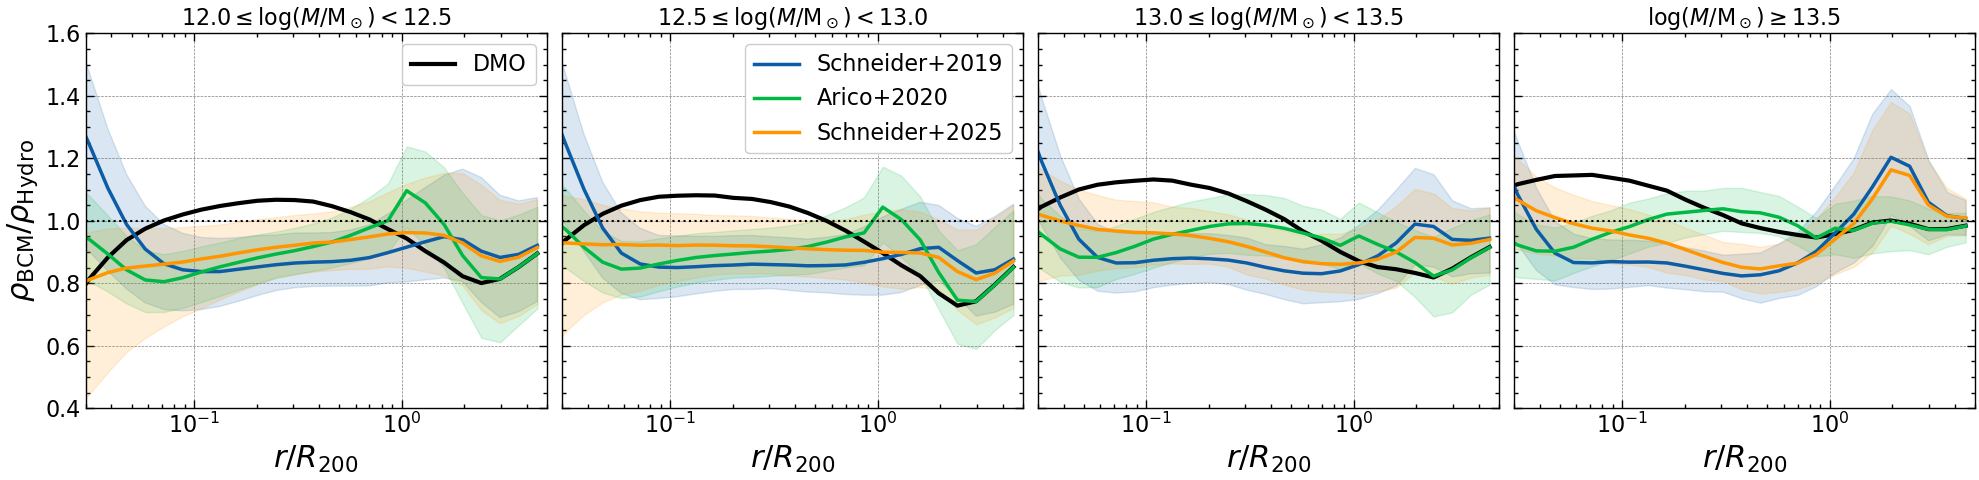

In [11]:
# =============================================================================
# Figure 1: Individual profile comparison in mass bins (1x4 grid)
# =============================================================================
# Show the SPREAD of individual BCM/Hydro ratios with thick lines and shaded regions

# Identify which bins have halos (graceful handling for empty bins)
active_bins = [bi for bi in range(n_mass_bins) if n_halos_per_bin[bi] > 0]
n_active = len(active_bins)
print(f"Active bins with halos: {active_bins} ({n_active} total)")
labels = ['Schneider+2019', 'Arico+2020', 'Schneider+2025']

# 1 row x 4 columns layout
fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True,
                        )

# Select representative BCM models to compare
models_to_plot = ['Schneider19', 'Arico20', 'Schneider25']
colors = {'Schneider19': 'C0', 'Arico20': 'C1', 'Schneider25': 'C2'}
labels = ['Schneider+2019', 'Arico+2020', 'Schneider+2025']

# models_to_plot = ['Arico20']
# colors = {'Arico20': 'C1'}
# labels = ['Arico+2020']


for plot_idx, bi in enumerate(active_bins):
    ax = axs[plot_idx]
    mask = mass_bin_indices == bi
    n_in_bin = mask.sum()
    
    # Plot DMO/Hydro with shaded region
    dmo_ratios = dmo_metrics['ratio_dmo_hydro'][mask]
    p50_dmo = np.nanpercentile(dmo_ratios, 50, axis=0)
    p16_dmo = np.nanpercentile(dmo_ratios, 16, axis=0)
    p84_dmo = np.nanpercentile(dmo_ratios, 84, axis=0)
    # Only add DMO label in first panel
    dmo_label = 'DMO' if plot_idx == 0 else None
    ax.semilogx(r, p50_dmo, 'k-', lw=3, label=dmo_label)
    # ax.fill_between(r, p16_dmo, p84_dmo, color='gray', alpha=0.2)
    
    # Plot BCM models with thick lines and shaded regions
    for ii, model_name in enumerate(models_to_plot):
        if model_name not in bcm_metrics:
            continue
        bcm_ratios = bcm_metrics[model_name]['ratio_bcm_hydro'][mask]
        p50 = np.nanpercentile(bcm_ratios, 50, axis=0)
        p16 = np.nanpercentile(bcm_ratios, 16, axis=0)
        p84 = np.nanpercentile(bcm_ratios, 84, axis=0)
        
        c = colors[model_name]
        # Only add BCM labels in second panel
        bcm_label = labels[ii] if plot_idx == 1 else None
        ax.semilogx(r, p50, color=c, lw=2.5, label=bcm_label)
        ax.fill_between(r, p16, p84, color=c, alpha=0.15)
    
    # Reference line
    ax.axhline(1, color='k', ls=':', lw=1.5)
    
    # Labels
    ax.set_title(f'{mass_bin_labels[bi]}')
    ax.set_xlim(0.03, 5)
    ax.set_ylim(0.4, 1.6)
    ax.set_xlabel(r'$r / R_{200}$', fontsize=22)

# Hide unused axes if fewer than 4 active bins
for i in range(n_active, 4):
    axs[i].set_visible(False)

axs[0].set_ylabel(r'$\rho_{\rm BCM} / \rho_{\rm Hydro}$', fontsize=22)
axs[0].legend(loc='best')
axs[1].legend(loc='best', ncols=1)

plt.tight_layout()
plt.savefig('./figures/BCM_individual_profiles_by_mass.pdf', bbox_inches='tight')
plt.show()

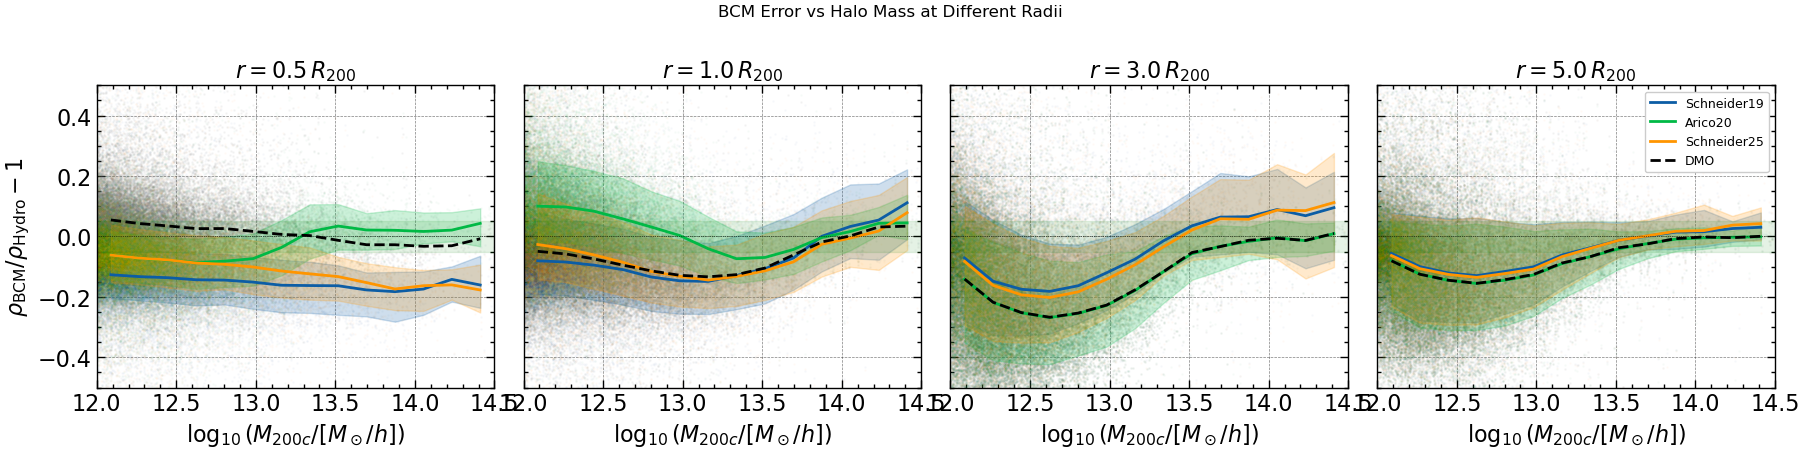

In [6]:
# =============================================================================
# Figure 2: BCM error as a function of halo mass (continuous)
# =============================================================================
# Instead of mass bins, show error vs mass as scatter + binned medians

fig, axs = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

r_targets = [0.5, 1.0, 3.0, 5.0]
models_to_plot = ['Schneider19', 'Arico20', 'Schneider25']

for i, r_target in enumerate(r_targets):
    ax = axs[i]
    
    # DMO error at this radius (background scatter)
    dmo_err = dmo_metrics['error_at_r'][r_target]
    ax.scatter(halo_log_masses, dmo_err, c='gray', s=1, alpha=0.05, rasterized=True)
    
    # BCM models
    for model_name in models_to_plot:
        bcm_err = bcm_metrics[model_name]['error_at_r'][r_target]
        c = colors[model_name]
        
        # Scatter (very faint)
        ax.scatter(halo_log_masses, bcm_err, c=c, s=1, alpha=0.02, rasterized=True)
        
        # Binned median with error bars
        mass_edges = np.linspace(12, 14.5, 15)
        mass_centers = 0.5 * (mass_edges[:-1] + mass_edges[1:])
        medians = []
        p16s, p84s = [], []
        
        for j in range(len(mass_centers)):
            mask = (halo_log_masses >= mass_edges[j]) & (halo_log_masses < mass_edges[j+1])
            if mask.sum() > 10:
                medians.append(np.nanmedian(bcm_err[mask]))
                p16s.append(np.nanpercentile(bcm_err[mask], 16))
                p84s.append(np.nanpercentile(bcm_err[mask], 84))
            else:
                medians.append(np.nan)
                p16s.append(np.nan)
                p84s.append(np.nan)
        
        medians = np.array(medians)
        p16s, p84s = np.array(p16s), np.array(p84s)
        
        ax.plot(mass_centers, medians, color=c, lw=2, label=model_name)
        ax.fill_between(mass_centers, p16s, p84s, color=c, alpha=0.2)
    
    # DMO binned median
    dmo_medians = []
    for j in range(len(mass_centers)):
        mask = (halo_log_masses >= mass_edges[j]) & (halo_log_masses < mass_edges[j+1])
        if mask.sum() > 10:
            dmo_medians.append(np.nanmedian(dmo_err[mask]))
        else:
            dmo_medians.append(np.nan)
    ax.plot(mass_centers, dmo_medians, 'k--', lw=2, label='DMO')
    
    ax.axhline(0, color='k', ls=':', lw=0.5)
    ax.fill_between([11.5, 15], -0.05, 0.05, color='green', alpha=0.1)
    ax.set_xlabel(r'$\log_{10}(M_{200c} / [M_\odot/h])$')
    ax.set_title(f'$r = {r_target}\\, R_{{200}}$')
    ax.set_xlim(12, 14.5)
    ax.set_ylim(-0.5, 0.5)

axs[0].set_ylabel(r'$\rho_{\rm BCM}/\rho_{\rm Hydro} - 1$')
axs[-1].legend(loc='upper right', fontsize=9)

plt.suptitle('BCM Error vs Halo Mass at Different Radii', y=1.02)
plt.tight_layout()
plt.savefig('./figures/BCM_error_vs_mass.pdf', bbox_inches='tight')
plt.show()

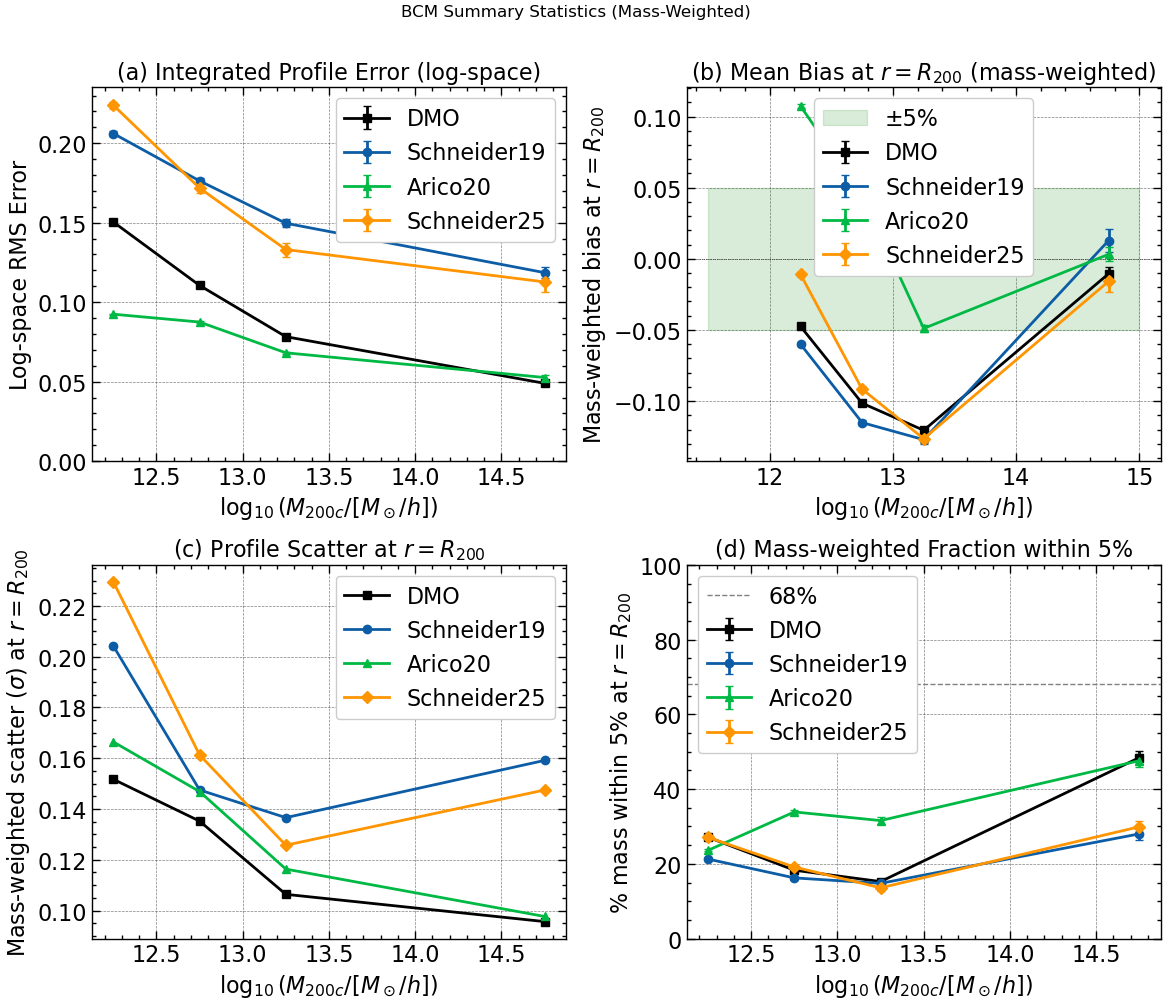

In [7]:
# =============================================================================
# Figure 3: Summary statistics - which BCM model is best? (MASS-WEIGHTED)
# =============================================================================
# Compare models using mass-weighted metrics per mass bin

def compute_bin_statistics_weighted(metrics, mass_bin_indices, mass_bin_edges, r, halo_masses):
    """
    Compute mass-weighted summary statistics for each mass bin.
    Properly propagates errors using weighted statistics.
    """
    n_bins = len(mass_bin_edges) - 1
    
    stats = {
        'mass_centers': 0.5 * (mass_bin_edges[:-1] + mass_bin_edges[1:]),
        'n_halos': np.zeros(n_bins),
        # Log-space RMS error (integrated)
        'log_rms_mean': np.zeros(n_bins),
        'log_rms_std': np.zeros(n_bins),
        'log_rms_sem': np.zeros(n_bins),
        # Bias at r=1.0 R200
        'bias_r10_mean': np.zeros(n_bins),
        'bias_r10_std': np.zeros(n_bins),
        'bias_r10_sem': np.zeros(n_bins),
        # Scatter at r=1.0 R200 (this is the weighted std)
        'scatter_r10': np.zeros(n_bins),
        # Fraction within 5% (mass-weighted)
        'fraction_within_5pct': np.zeros(n_bins),
        'fraction_within_5pct_err': np.zeros(n_bins),
    }
    
    for bi in range(n_bins):
        mask = mass_bin_indices == bi
        n = mask.sum()
        stats['n_halos'][bi] = n
        
        if n == 0:
            for key in stats:
                if key not in ['mass_centers', 'n_halos']:
                    stats[key][bi] = np.nan
            continue
        
        masses_in_bin = halo_masses[mask]
        
        # Log-space RMS error (mass-weighted)
        log_rms = metrics['log_rms_error'][mask]
        mean, std, sem = weighted_mean_and_error(log_rms, masses_in_bin)
        stats['log_rms_mean'][bi] = mean
        stats['log_rms_std'][bi] = std
        stats['log_rms_sem'][bi] = sem
        
        # Bias at r=1.0 R200 (mass-weighted)
        err_r10 = metrics['error_at_r'][1.0][mask]
        mean, std, sem = weighted_mean_and_error(err_r10, masses_in_bin)
        stats['bias_r10_mean'][bi] = mean
        stats['bias_r10_std'][bi] = std
        stats['bias_r10_sem'][bi] = sem
        stats['scatter_r10'][bi] = std  # scatter IS the weighted std
        
        # Fraction within 5% at r=1.0 R200 (mass-weighted)
        within_5pct = (np.abs(err_r10) < 0.05).astype(float)
        valid_mask = np.isfinite(err_r10) & (masses_in_bin > 0)
        if valid_mask.sum() > 0:
            w = masses_in_bin[valid_mask] / masses_in_bin[valid_mask].sum()
            frac = np.sum(w * within_5pct[valid_mask])
            # Binomial-like error for weighted fraction
            frac_err = np.sqrt(frac * (1 - frac) / valid_mask.sum())
            stats['fraction_within_5pct'][bi] = frac
            stats['fraction_within_5pct_err'][bi] = frac_err
        else:
            stats['fraction_within_5pct'][bi] = np.nan
            stats['fraction_within_5pct_err'][bi] = np.nan
    
    return stats

# Compute mass-weighted stats for all models
all_stats = {}
for model_name, metrics in bcm_metrics.items():
    all_stats[model_name] = compute_bin_statistics_weighted(
        metrics, mass_bin_indices, mass_bin_edges, r, halo_masses_linear
    )

# DMO stats for reference
all_stats['DMO'] = compute_bin_statistics_weighted(
    dmo_metrics, mass_bin_indices, mass_bin_edges, r, halo_masses_linear
)

# --- Plot comparison ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

models_to_compare = ['DMO', 'Schneider19', 'Arico20', 'Schneider25']
markers = {'DMO': 's', 'Schneider19': 'o', 'Arico20': '^', 'Schneider25': 'D'}
colors_ext = {'DMO': 'black', 'Schneider19': 'C0', 'Arico20': 'C1', 'Schneider25': 'C2'}

# Only plot bins with halos
active_bins = [bi for bi in range(n_mass_bins) if n_halos_per_bin[bi] > 0]
x_positions = [all_stats['DMO']['mass_centers'][bi] for bi in active_bins]

# Panel A: Log-space RMS error (mass-weighted)
ax = axs[0, 0]
for model in models_to_compare:
    stats = all_stats[model]
    y = [stats['log_rms_mean'][bi] for bi in active_bins]
    yerr = [stats['log_rms_sem'][bi] for bi in active_bins]
    ax.errorbar(x_positions, y, yerr=yerr, marker=markers[model], 
                color=colors_ext[model], label=model, lw=2, capsize=3)
ax.set_xlabel(r'$\log_{10}(M_{200c} / [M_\odot/h])$')
ax.set_ylabel('Log-space RMS Error')
ax.legend()
ax.set_title('(a) Integrated Profile Error (log-space)')
ax.set_ylim(0, None)

# Panel B: Mean bias at r=1.0 R200 (mass-weighted)
ax = axs[0, 1]
for model in models_to_compare:
    stats = all_stats[model]
    y = [stats['bias_r10_mean'][bi] for bi in active_bins]
    yerr = [stats['bias_r10_sem'][bi] for bi in active_bins]
    ax.errorbar(x_positions, y, yerr=yerr, marker=markers[model], 
                color=colors_ext[model], label=model, lw=2, capsize=3)
ax.axhline(0, color='k', ls=':', lw=0.5)
ax.fill_between([11.5, 15], -0.05, 0.05, color='green', alpha=0.15, label='±5%')
ax.set_xlabel(r'$\log_{10}(M_{200c} / [M_\odot/h])$')
ax.set_ylabel(r'Mass-weighted bias at $r = R_{200}$')
ax.legend()
ax.set_title(r'(b) Mean Bias at $r = R_{200}$ (mass-weighted)')

# Panel C: Scatter at r=1.0 R200
ax = axs[1, 0]
for model in models_to_compare:
    stats = all_stats[model]
    y = [stats['scatter_r10'][bi] for bi in active_bins]
    ax.plot(x_positions, y, marker=markers[model], color=colors_ext[model], 
            label=model, lw=2)
ax.set_xlabel(r'$\log_{10}(M_{200c} / [M_\odot/h])$')
ax.set_ylabel(r'Mass-weighted scatter ($\sigma$) at $r = R_{200}$')
ax.legend()
ax.set_title(r'(c) Profile Scatter at $r = R_{200}$')

# Panel D: Fraction within 5% (mass-weighted)
ax = axs[1, 1]
for model in models_to_compare:
    stats = all_stats[model]
    y = [stats['fraction_within_5pct'][bi] * 100 for bi in active_bins]
    yerr = [stats['fraction_within_5pct_err'][bi] * 100 for bi in active_bins]
    ax.errorbar(x_positions, y, yerr=yerr, marker=markers[model], 
                color=colors_ext[model], label=model, lw=2, capsize=3)
ax.axhline(68, color='gray', ls='--', lw=1, label='68%')
ax.set_xlabel(r'$\log_{10}(M_{200c} / [M_\odot/h])$')
ax.set_ylabel(r'% mass within 5% at $r = R_{200}$')
ax.legend()
ax.set_title(r'(d) Mass-weighted Fraction within 5%')
ax.set_ylim(0, 100)

plt.suptitle('BCM Summary Statistics (Mass-Weighted)', y=1.01)
plt.tight_layout()
plt.savefig('./figures/BCM_summary_statistics.pdf', bbox_inches='tight')
plt.show()

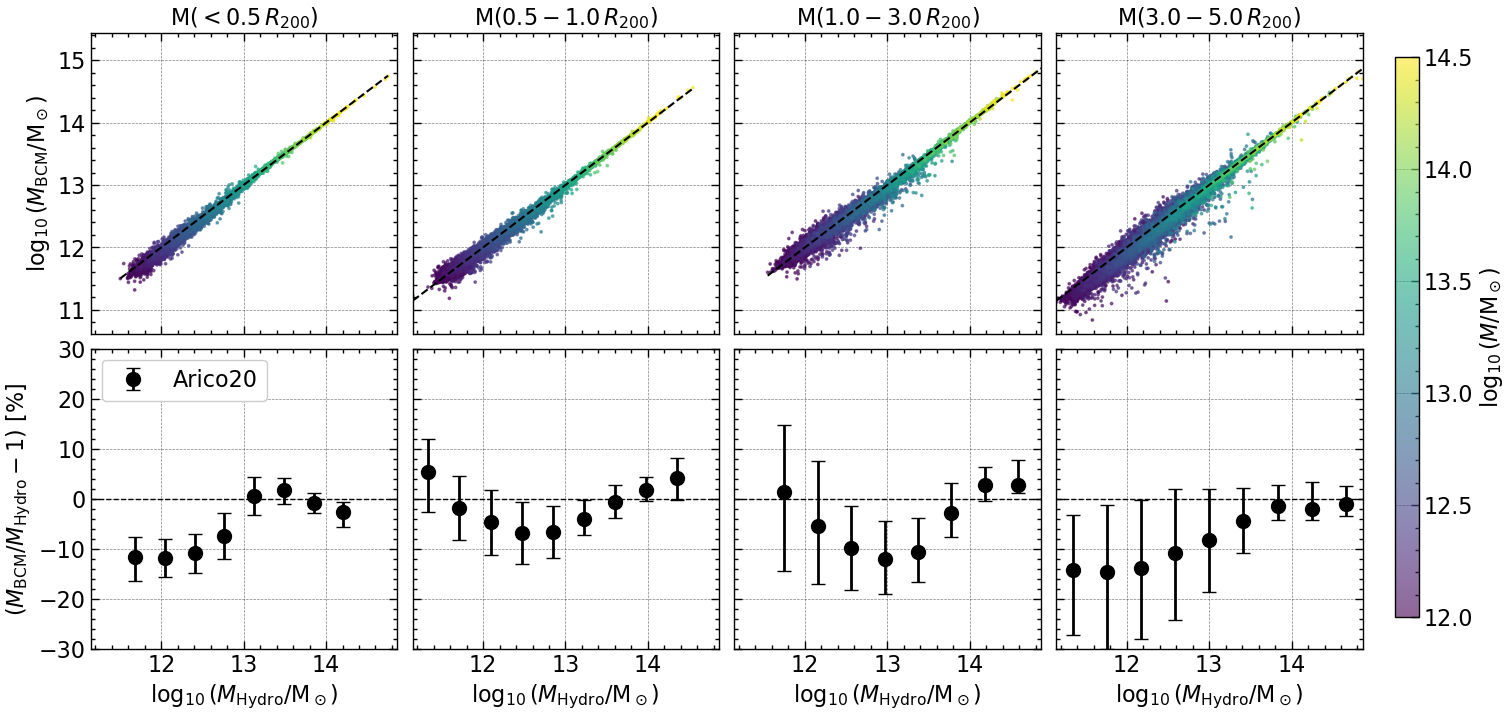

In [16]:
# =============================================================================
# Figure 4: Halo-by-halo scatter plots - Integrated mass in radial shells
# =============================================================================
# Compare integrated masses within radial shells: BCM vs TNG Hydro

def compute_shell_mass(density_profiles, r, r_bins, halo_radii, r_inner, r_outer):
    """
    Compute integrated mass within a radial shell [r_inner, r_outer] in units of R200.
    
    density_profiles: (n_halos, n_radii) density at each radius
    r: radial bin centers in units of R200
    r_bins: radial bin edges in units of R200
    halo_radii: R200 in kpc/h for each halo
    r_inner, r_outer: shell boundaries in units of R200
    
    Returns: (n_halos,) integrated mass in each shell
    """
    n_halos = density_profiles.shape[0]
    shell_masses = np.zeros(n_halos)
    
    for i in range(n_halos):
        R200_kpc = halo_radii[i]  # kpc/h
        
        # Select radial bins within the shell
        mask = (r >= r_inner) & (r <= r_outer)
        
        if mask.sum() == 0:
            shell_masses[i] = np.nan
            continue
        
        # Integrate: M = ∫ 4πr² ρ(r) dr
        # Convert r from R200 units to kpc/h
        r_phys = r[mask] * R200_kpc  # kpc/h
        dr = np.diff(r_bins)[mask] * R200_kpc  # kpc/h
        rho = density_profiles[i, mask]  # density (Msun/h / (kpc/h)^3)
        
        # Shell volume elements: 4πr² dr
        dM = 4 * np.pi * r_phys**2 * rho * dr
        shell_masses[i] = np.nansum(dM)
    
    return shell_masses

# Define radial shells
shells = [
    (0.0, 0.5, r'${\rm M}(<0.5\,R_{200})$'),
    (0.5, 1.0, r'${\rm M}(0.5-1.0\,R_{200})$'),
    (1.0, 3.0, r'${\rm M}(1.0-3.0\,R_{200})$'),
    (3.0, 5.0, r'${\rm M}(3.0-5.0\,R_{200})$'),
]

# Choose BCM model
bcm_model = 'Arico20'
bcm_individual = bcm_models[bcm_model]['individual']

# Compute shell masses for Hydro, BCM, and DMO
shell_masses_hydro = {}
shell_masses_bcm = {}
shell_masses_dmo = {}

for r_in, r_out, label in shells:
    shell_masses_hydro[(r_in, r_out)] = compute_shell_mass(
        tng_hydro_individual, r, r_bins, halo_radii, r_in, r_out)
    shell_masses_bcm[(r_in, r_out)] = compute_shell_mass(
        bcm_individual, r, r_bins, halo_radii, r_in, r_out)
    shell_masses_dmo[(r_in, r_out)] = compute_shell_mass(
        tng_dmo_individual, r, r_bins, halo_radii, r_in, r_out)

# --- Plot: 2 rows (scatter on top, residuals on bottom) with shared axes ---
fig, axs = plt.subplots(2, 4, figsize=(16, 8), 
                        gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.05, 'wspace':0.05},
                        sharex=True, sharey='row')

for col, (r_in, r_out, label) in enumerate(shells):
    ax_top = axs[0, col]
    ax_bot = axs[1, col]
    
    M_hydro = shell_masses_hydro[(r_in, r_out)]
    M_bcm = shell_masses_bcm[(r_in, r_out)]
    M_dmo = shell_masses_dmo[(r_in, r_out)]
    
    # Valid data
    valid = (M_hydro > 0) & (M_bcm > 0) & np.isfinite(M_hydro) & np.isfinite(M_bcm)
    valid_dmo = (M_hydro > 0) & (M_dmo > 0) & np.isfinite(M_hydro) & np.isfinite(M_dmo)
    
    # Sort by mass so massive halos appear on top
    sort_idx = np.argsort(halo_log_masses[valid])
    
    # --- Top panel: M_BCM vs M_Hydro ---
    sc = ax_top.scatter(np.log10(M_hydro[valid])[sort_idx], 
                        np.log10(M_bcm[valid])[sort_idx],
                        c=halo_log_masses[valid][sort_idx], cmap='viridis', 
                        s=3, alpha=0.6, vmin=12, vmax=14.5, rasterized=True)
    
    # 1:1 line
    lims = [np.log10(M_hydro[valid]).min(), np.log10(M_hydro[valid]).max()]
    ax_top.plot(lims, lims, 'k--', lw=1.5)
    
    # Correlation
    from scipy.stats import pearsonr
    corr, _ = pearsonr(np.log10(M_hydro[valid]), np.log10(M_bcm[valid]))
    
    ax_top.set_title(label)
    if col == 0:
        ax_top.set_ylabel(r'$\log_{10}(M_{\rm BCM}/ {\rm M}_\odot)$')
    
    # --- Bottom panel: Relative difference vs M_Hydro with errorbars ---
    rel_diff = (M_bcm[valid] / M_hydro[valid] - 1) * 100  # in percent
    rel_diff_dmo = (M_dmo[valid_dmo] / M_hydro[valid_dmo] - 1) * 100  # DMO in percent
    log_M = np.log10(M_hydro[valid])
    log_M_dmo = np.log10(M_hydro[valid_dmo])
    
    # Reference lines
    ax_bot.axhline(0, color='k', ls='--', lw=1)
    
    # Binned statistics for BCM with errorbars
    mass_edges = np.linspace(log_M.min(), log_M.max(), 10)
    mass_centers = 0.5 * (mass_edges[:-1] + mass_edges[1:])
    medians = []
    err_low, err_high = [], []
    
    for j in range(len(mass_centers)):
        mask_bin = (log_M >= mass_edges[j]) & (log_M < mass_edges[j+1])
        if mask_bin.sum() > 5:
            med = np.nanmean(rel_diff[mask_bin])
            p16 = np.nanpercentile(rel_diff[mask_bin], 16)
            p84 = np.nanpercentile(rel_diff[mask_bin], 84)
            medians.append(med)
            err_low.append(med - p16)
            err_high.append(p84 - med)
        else:
            medians.append(np.nan)
            err_low.append(np.nan)
            err_high.append(np.nan)
    
    medians = np.array(medians)
    err_low = np.array(err_low)
    err_high = np.array(err_high)
    
    # Binned statistics for DMO with errorbars
    medians_dmo = []
    err_low_dmo, err_high_dmo = [], []
    
    for j in range(len(mass_centers)):
        mask_bin = (log_M_dmo >= mass_edges[j]) & (log_M_dmo < mass_edges[j+1])
        if mask_bin.sum() > 5:
            med = np.nanmean(rel_diff_dmo[mask_bin])
            p16 = np.nanpercentile(rel_diff_dmo[mask_bin], 16)
            p84 = np.nanpercentile(rel_diff_dmo[mask_bin], 84)
            medians_dmo.append(med)
            err_low_dmo.append(med - p16)
            err_high_dmo.append(p84 - med)
        else:
            medians_dmo.append(np.nan)
            err_low_dmo.append(np.nan)
            err_high_dmo.append(np.nan)
    
    medians_dmo = np.array(medians_dmo)
    err_low_dmo = np.array(err_low_dmo)
    err_high_dmo = np.array(err_high_dmo)
    
    # Plot DMO with errorbars (gray)
    # ax_bot.errorbar(mass_centers, medians_dmo, yerr=[err_low_dmo, err_high_dmo], 
    #                 fmt='s', color='gray', markersize=5, capsize=3, lw=1.5,
    #                 label='DMO' if col == 0 else None)
    
    # Plot BCM with errorbars (black)
    ax_bot.errorbar(mass_centers, medians, yerr=[err_low, err_high], 
                    fmt='o', color='k', markersize=10, capsize=5, lw=2.,
                    label='Arico20' if col == 0 else None)
    
    ax_bot.set_xlabel(r'$\log_{10}(M_{\rm Hydro}/{\rm M}_\odot)$')
    if col == 0:
        ax_bot.set_ylabel(r'$(M_{\rm BCM}/M_{\rm Hydro} - 1)$ [%]')
        ax_bot.legend(loc='upper left')
    ax_bot.set_ylim(-30, 30)
    ax_bot.set_xlim(lims)
   
# Colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label(r'$\log_{10}(M / {\rm M}_\odot)$')

plt.savefig('./figures/BCM_shell_mass_comparison.pdf', bbox_inches='tight')
plt.show()

In [3]:
# =============================================================================
# Figure 5: Shell mass residuals for multiple BCM models
# =============================================================================
# Compare Schneider19, Arico20, Schneider25 shell mass predictions vs TNG Hydro

# Define radial shells (same as Figure 4)
shells = [
    (0.0, 0.5, r'$M(<0.5\,R_{200})$'),
    (0.5, 1.0, r'$M(0.5-1.0\,R_{200})$'),
    (1.0, 3.0, r'$M(1.0-3.0\,R_{200})$'),
    (3.0, 5.0, r'$M(3.0-5.0\,R_{200})$'),
]

# BCM models to compare
models_to_compare = ['Schneider19', 'Arico20', 'Schneider25']
model_colors = {'Schneider19': 'C0', 'Arico20': 'C1', 'Schneider25': 'C2'}
model_markers = {'Schneider19': 'o', 'Arico20': 's', 'Schneider25': '^'}

# Compute shell masses for each BCM model
shell_masses_models = {}
for model_name in models_to_compare:
    if model_name not in bcm_models:
        continue
    bcm_individual = bcm_models[model_name]['individual']
    shell_masses_models[model_name] = {}
    for r_in, r_out, label in shells:
        shell_masses_models[model_name][(r_in, r_out)] = compute_shell_mass(
            bcm_individual, r, r_bins, halo_radii, r_in, r_out)

# Compute shell masses for Hydro (reference)
shell_masses_hydro = {}
for r_in, r_out, label in shells:
    shell_masses_hydro[(r_in, r_out)] = compute_shell_mass(
        tng_hydro_individual, r, r_bins, halo_radii, r_in, r_out)

# --- Plot: 1 row of 4 panels (residuals only) with shared axes ---
fig, axs = plt.subplots(1, 4, figsize=(16, 4), 
                        gridspec_kw={'wspace': 0.05},
                        sharex=True, sharey=True)

for col, (r_in, r_out, label) in enumerate(shells):
    ax = axs[col]
    
    M_hydro = shell_masses_hydro[(r_in, r_out)]
    valid_hydro = (M_hydro > 0) & np.isfinite(M_hydro)
    log_M_hydro = np.log10(M_hydro[valid_hydro])
    lims = [log_M_hydro.min(), log_M_hydro.max()]
    
    # Reference lines
    ax.axhline(0, color='k', ls='--', lw=1)
    ax.fill_between(lims, -5, 5, color='green', alpha=0.15)
    
    # Plot each BCM model
    for model_name in models_to_compare:
        if model_name not in shell_masses_models:
            continue
        
        M_bcm = shell_masses_models[model_name][(r_in, r_out)]
        valid = valid_hydro & (M_bcm > 0) & np.isfinite(M_bcm)
        
        rel_diff = (M_bcm[valid] / M_hydro[valid] - 1) * 100  # in percent
        log_M = np.log10(M_hydro[valid])
        
        # Binned statistics with errorbars
        mass_edges = np.linspace(log_M.min(), log_M.max(), 10)
        mass_centers = 0.5 * (mass_edges[:-1] + mass_edges[1:])
        medians = []
        err_low, err_high = [], []
        
        for j in range(len(mass_centers)):
            mask_bin = (log_M >= mass_edges[j]) & (log_M < mass_edges[j+1])
            if mask_bin.sum() > 5:
                med = np.nanmedian(rel_diff[mask_bin])
                p16 = np.nanpercentile(rel_diff[mask_bin], 16)
                p84 = np.nanpercentile(rel_diff[mask_bin], 84)
                medians.append(med)
                err_low.append(med - p16)
                err_high.append(p84 - med)
            else:
                medians.append(np.nan)
                err_low.append(np.nan)
                err_high.append(np.nan)
        
        medians = np.array(medians)
        err_low = np.array(err_low)
        err_high = np.array(err_high)
        
        # Plot with errorbars
        ax.errorbar(mass_centers, medians, yerr=[err_low, err_high], 
                    fmt=model_markers[model_name], color=model_colors[model_name], 
                    markersize=5, capsize=3, lw=1.5, label=model_name)
    
    ax.set_xlabel(r'$\log_{10}(M_{\rm Hydro}\, [M_\odot/h])$')
    ax.set_title(label)
    ax.set_ylim(-30, 30)
    ax.set_xlim(lims)

axs[0].set_ylabel(r'$(M_{\rm BCM}/M_{\rm Hydro} - 1)$ [%]')
axs[-1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('./figures/BCM_shell_mass_residuals_models.pdf', bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nShell Mass Comparison Summary (BCM/Hydro - 1):")
print("-" * 70)
for model_name in models_to_compare:
    if model_name not in shell_masses_models:
        continue
    print(f"\n{model_name}:")
    for r_in, r_out, label in shells:
        M_hydro = shell_masses_hydro[(r_in, r_out)]
        M_bcm = shell_masses_models[model_name][(r_in, r_out)]
        valid = (M_hydro > 0) & (M_bcm > 0) & np.isfinite(M_hydro) & np.isfinite(M_bcm)
        ratio = M_bcm[valid] / M_hydro[valid]
        print(f"  {label:25s}: median = {np.median(ratio)-1:+.1%}, "
              f"16-84% = [{np.percentile(ratio,16)-1:+.1%}, {np.percentile(ratio,84)-1:+.1%}]")

NameError: name 'bcm_models' is not defined

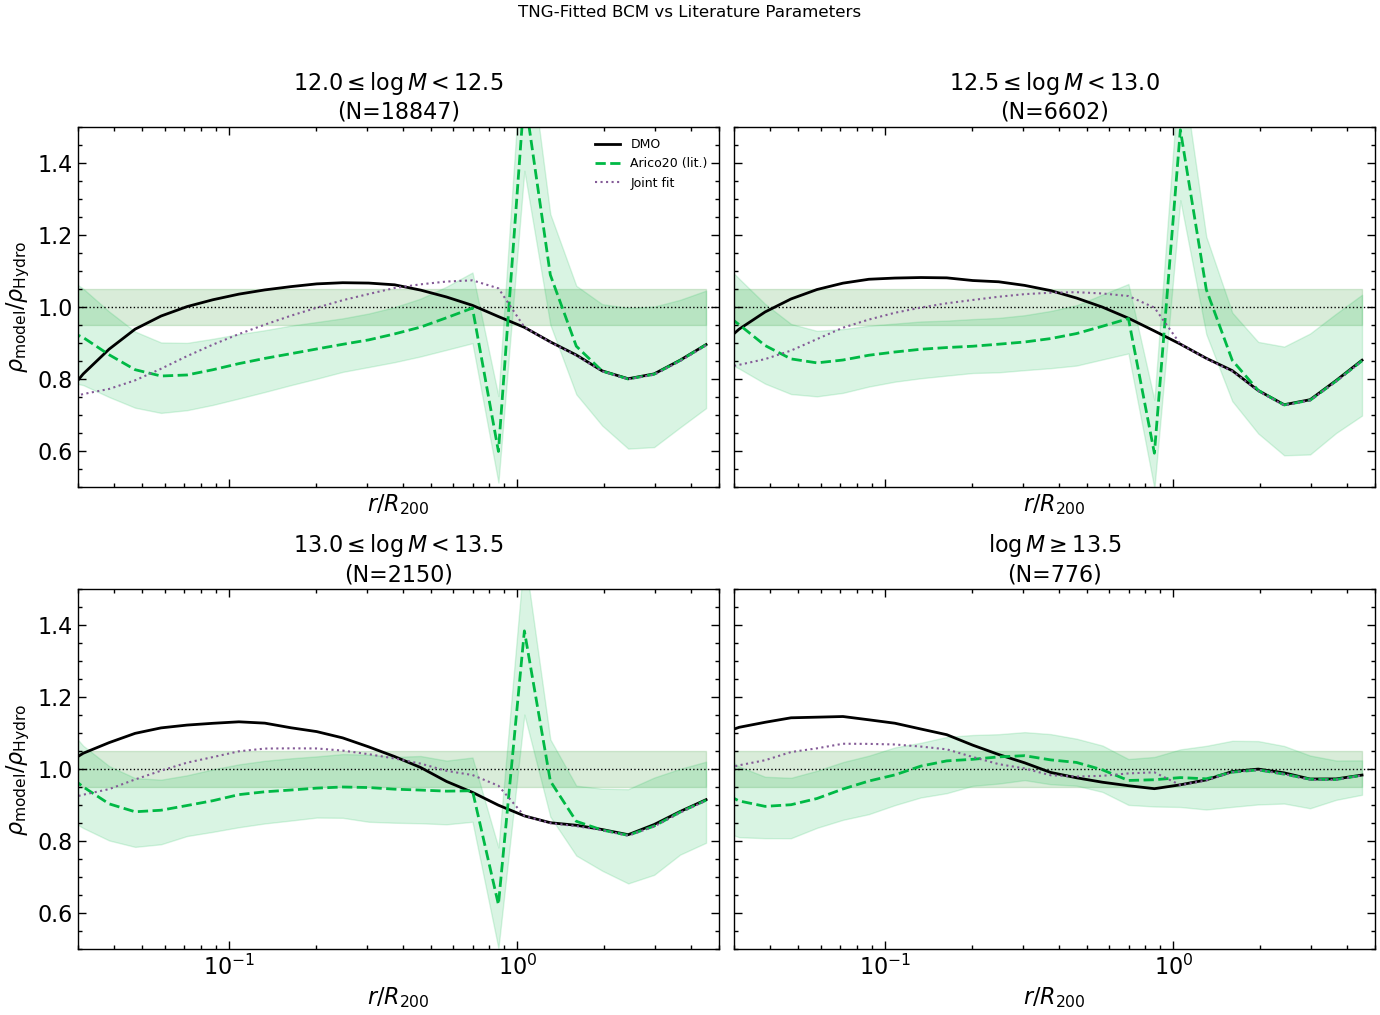

In [17]:
# =============================================================================
# Figure 6: Mass-dependent TNG fits comparison (graceful empty bin handling)
# =============================================================================
# Compare the TNG-fitted Arico20 models against the literature parameters

# Identify which bins have halos
active_bins = [bi for bi in range(n_mass_bins) if n_halos_per_bin[bi] > 0]
n_active = len(active_bins)

# Dynamic grid
if n_active <= 2:
    fig, axs = plt.subplots(1, n_active, figsize=(7*n_active, 5), squeeze=False)
    axs_flat = axs.flatten()
elif n_active == 3:
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs_flat = axs.flatten() if hasattr(axs, 'flatten') else [axs]
else:
    fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
    axs_flat = axs.flatten()

# Map mass bins to the appropriate TNG fit
tng_fit_for_bin = {
    0: 'Arico20_TNG_Mlow',      # 12.0-12.5
    1: 'Arico20_TNG_Mmid_low',  # 12.5-13.0
    2: 'Arico20_TNG_Mmid_high', # 13.0-13.5
    3: 'Arico20_TNG_Mhigh',     # >13.5
}

for plot_idx, bi in enumerate(active_bins):
    ax = axs_flat[plot_idx]
    mask = mass_bin_indices == bi
    n = mask.sum()
    
    # TNG Hydro reference (median ratio to hydro = 1)
    ax.axhline(1, color='k', ls=':', lw=1)
    ax.fill_between(r, 0.95, 1.05, color='green', alpha=0.15)
    
    # DMO/Hydro
    dmo_ratio = tng_dmo_individual[mask] / tng_hydro_individual[mask]
    ax.semilogx(r, np.nanmedian(dmo_ratio, axis=0), 'k-', lw=2, label='DMO')
    
    # Literature Arico20
    if 'Arico20' in bcm_metrics:
        bcm_ratio = bcm_metrics['Arico20']['ratio_bcm_hydro'][mask]
        ax.semilogx(r, np.nanmedian(bcm_ratio, axis=0), 'C1--', lw=2, label='Arico20 (lit.)')
        ax.fill_between(r, np.nanpercentile(bcm_ratio, 16, axis=0),
                       np.nanpercentile(bcm_ratio, 84, axis=0), color='C1', alpha=0.15)
    
    # TNG-fitted Arico20 (mass-specific)
    tng_fit_name = tng_fit_for_bin.get(bi)
    if tng_fit_name and tng_fit_name in bcm_metrics:
        bcm_ratio = bcm_metrics[tng_fit_name]['ratio_bcm_hydro'][mask]
        ax.semilogx(r, np.nanmedian(bcm_ratio, axis=0), 'C3-', lw=2, 
                   label=f'{tng_fit_name.replace("Arico20_TNG_", "")}')
        ax.fill_between(r, np.nanpercentile(bcm_ratio, 16, axis=0),
                       np.nanpercentile(bcm_ratio, 84, axis=0), color='C3', alpha=0.15)
    
    # Joint fit for comparison
    if 'Arico20_TNG_joint' in bcm_metrics:
        bcm_ratio = bcm_metrics['Arico20_TNG_joint']['ratio_bcm_hydro'][mask]
        ax.semilogx(r, np.nanmedian(bcm_ratio, axis=0), 'C4:', lw=1.5, label='Joint fit')
    
    ax.set_title(f'{mass_bin_labels[bi]}\n(N={n})')
    ax.set_xlim(0.03, 5)
    ax.set_ylim(0.5, 1.5)
    ax.set_xlabel(r'$r / R_{200}$')

# Hide unused axes
if n_active < len(axs_flat):
    for i in range(n_active, len(axs_flat)):
        axs_flat[i].set_visible(False)

axs_flat[0].set_ylabel(r'$\rho_{\rm model} / \rho_{\rm Hydro}$')
if n_active > 2:
    axs_flat[2].set_ylabel(r'$\rho_{\rm model} / \rho_{\rm Hydro}$')
axs_flat[0].legend(loc='upper right', fontsize=9)

plt.suptitle('TNG-Fitted BCM vs Literature Parameters', y=1.02)
plt.tight_layout()
plt.savefig('./figures/BCM_tng_fits_comparison.pdf', bbox_inches='tight')
plt.show()

In [18]:
# =============================================================================
# Table: Quantitative comparison of BCM models (MASS-WEIGHTED)
# =============================================================================

print("="*90)
print("BCM Model Performance Summary (MASS-WEIGHTED, at r = 1.0 R200)")
print("="*90)
print(f"{'Model':<25} {'Bias ± SEM':<18} {'Scatter':<12} {'% within 5%':<15}")
print("-"*90)

for model_name in ['DMO', 'Schneider19', 'Arico20', 'Schneider25', 
                   'Arico20_TNG_joint', 'Arico20_TNG_Mlow', 
                   'Arico20_TNG_Mmid_low', 'Arico20_TNG_Mmid_high', 
                   'Arico20_TNG_Mhigh']:
    if model_name not in all_stats:
        continue
    
    stats = all_stats[model_name]
    
    # Filter out bins with no halos
    valid_mask = stats['n_halos'] > 0
    if valid_mask.sum() == 0:
        continue
    
    # Mass-weight the bin statistics (higher-mass bins get more weight)
    bin_masses = np.array([n_halos_per_bin[bi] * 10**(mass_bin_edges[bi] + 0.25) 
                          for bi in range(n_mass_bins)])
    weights = bin_masses[valid_mask] / bin_masses[valid_mask].sum()
    
    mean_bias = np.average(stats['bias_r10_mean'][valid_mask], weights=weights)
    mean_sem = np.sqrt(np.sum((weights * stats['bias_r10_sem'][valid_mask])**2))
    mean_scatter = np.average(stats['scatter_r10'][valid_mask], weights=weights)
    mean_frac = np.average(stats['fraction_within_5pct'][valid_mask], weights=weights) * 100
    
    print(f"{model_name:<25} {mean_bias:>+.3f} ± {mean_sem:.3f}    {mean_scatter:.3f}        {mean_frac:.1f}%")

print("="*90)
print("\nNote: Positive bias = BCM overpredicts density relative to TNG Hydro")
print("      All statistics are MASS-WEIGHTED (higher-mass halos contribute more)")

# More detailed breakdown by mass bin
print("\n" + "="*90)
print("Breakdown by Mass Bin: Mass-weighted Bias ± SEM at r = R200")
print("="*90)
header = f"{'Model':<20}"
for bi in range(len(mass_bin_edges)-1):
    if n_halos_per_bin[bi] > 0:
        header += f"  Bin{bi}(N={n_halos_per_bin[bi]:>4})"
print(header)
print("-"*90)

for model_name in ['DMO', 'Schneider19', 'Arico20', 'Schneider25']:
    if model_name not in all_stats:
        continue
    stats = all_stats[model_name]
    row = f"{model_name:<20}"
    for bi in range(len(mass_bin_edges)-1):
        if n_halos_per_bin[bi] > 0:
            bias = stats['bias_r10_mean'][bi]
            sem = stats['bias_r10_sem'][bi]
            row += f"  {bias:>+.2f}±{sem:.2f}"
    print(row)

BCM Model Performance Summary (MASS-WEIGHTED, at r = 1.0 R200)
Model                     Bias ± SEM         Scatter      % within 5%    
------------------------------------------------------------------------------------------
DMO                       -0.068 ± 0.002    0.120        28.1%
Schneider19               -0.069 ± 0.003    0.161        20.3%
Arico20                   +0.336 ± 0.002    0.196        16.4%
Schneider25               -0.061 ± 0.002    0.163        22.6%
Arico20_TNG_joint         -0.070 ± 0.002    0.123        27.9%

Note: Positive bias = BCM overpredicts density relative to TNG Hydro
      All statistics are MASS-WEIGHTED (higher-mass halos contribute more)

Breakdown by Mass Bin: Mass-weighted Bias ± SEM at r = R200
Model                 Bin0(N=18847)  Bin1(N=6602)  Bin2(N=2150)  Bin3(N= 776)
------------------------------------------------------------------------------------------
DMO                   -0.05±0.00  -0.10±0.00  -0.12±0.00  -0.01±0.00
Schneider19  